In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
import yfinance as yf
import numpy as np
import pickle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import seaborn as sns
import os 
import time
sns.set()
import OpenDartReader
from tqdm import tqdm
import requests

#### 1. 하이퍼 파라미터 정의

In [ ]:
# 다트 API KEY
dart_api_key = ''

# 다트/IFRS 계정 코드 mapper : 총자본, 매출액, 당기순이익
account_mapper = {
            'BS': {'총자본': ['ifrs-full_Equity', 'ifrs_Equity', 'ifrs-full_EquityAttributableToOwnersOfParent']},
            'CIS': {
                '매출액': ['ifrs-full_Revenue', 'dart_OperatingRevenue', 'ifrs_Revenue', 'ifrs-full_RevenueFromInterestsDividendsAndFees', 'ifrs-full_GrossProfit'], 
                '당기순이익': ['ifrs-full_ProfitLoss', 'ifrs_ProfitLoss', 'ifrs-full_ProfitLossAttributableToOwnersOfParent']},
            }

# KOSPI200 금융 섹터 종목 (제외)
fin_corps = ['KB금융', '삼성생명', '신한지주', '하나금융지주', '우리금융지주', '삼성화재', '메리츠금융지주', '기업은행', '한국금융지주', 'DB손해보험', 'NH투자증권', '삼성증권',
'삼성카드', 'BNK금융지주', 'JB금융지주', '한화생명', '현대해상', 'iM금융지주', '카카오페이']

# OpenDartReader 객체 
dart = OpenDartReader(dart_api_key)

# 종목명, 종목티커 mapper 
ticker_mapper = {stk_nm : ticker for ticker, stk_nm in pd.read_csv('./데이터/KOSPI200_종목티커정보.csv', encoding = 'cp949')[['종목코드',	'종목명']].iloc if not (stk_nm in fin_corps)}

#### 2. 다트 보고서 탐색 범위 지정 (개별 기업 단위)

In [ ]:
"""개별 기업 보고서 정보 필터링 함수"""
def initailize_date_range_info(ticker, period_begin_year, period_end) : 
    
    # 다트 종목 코드 추출
    corp_code = dart.find_corp_code(ticker)

    # 공시검색 개발가이드 URL
    url = 'https://opendart.fss.or.kr/api/list.json'

    # 공시검색 개발가이드 Parameter
    params = {'crtfc_key' : dart_api_key, 'corp_code' : corp_code, 'bgn_de' : f'{period_begin_year}0101', 'end_de' : period_end,
            # 원공시 + 기재정정       # 정기공시 유형
            'last_reprt_at' : 'N' , 'pblntf_ty' : 'A', 'page_no' : '10', 'page_count' : '100'}

    # 공시검색 개발가이드 데이터 요청
    report_info_res = requests.get(url, params=params).json()

    # 요청 성공 여부 확인 및 보고서 정보 데이터 추출
    if report_info_res['status'] == '000' :
        report_info_df = pd.DataFrame(report_info_res['list'])
    else:
        raise ValueError(f'DART API 에러 메세지: {report_info_res["message"]}')

    # 보고서 공개일 기준 정렬
    report_info_df = report_info_df.sort_values(by=['rcept_dt'])

    report_all_date_infos = report_info_df[['report_nm', 'rcept_dt']]

    # 탐색 기간 보고서 
    range_date_info = {}

    # 모든 보고서의 연도 및 월 매칭 정보 추출
    for report_info, report_date in report_all_date_infos.iloc :
        
        # 보고서 연도 및 월 추출
        idx_cut_start = report_info.find('(')
        idx_cut_end = report_info.find(')')
        year_month = report_info[idx_cut_start+1 : idx_cut_end]
        year = year_month[:4]
        month = year_month[5:]
        reprt_code = {'03' : '11013', '06' : '11012', '09' : '11014', '12' : '11011'}[month]

        # 연도 및 분기번호 매칭    
        if year in range_date_info :
            
            # 기재정정으로 추가로 매칭되는 경우
            if reprt_code in range_date_info[year].keys() :
                range_date_info[year][reprt_code].append(report_date)

            # 이미 있는 연도에 새로운 분기가 들어오는 경우 
            else :
                range_date_info[year][reprt_code] = [report_date]
        
        # 최초 연도인 경우 
        else : 
            range_date_info[year] = {reprt_code : [report_date]}

    # 기재정정을 제외한 최초 공개일과 매칭
    range_date_info = {year : {reprt_code : min(rcept_dates) for reprt_code, rcept_dates in qtype_date_info.items()} 
                       for year, qtype_date_info in range_date_info.items() if int(year) >= int(period_begin_year)}

    return range_date_info, corp_code

#### 3.  개별 기업의 특정 분기 보고서 gav 데이터 추출 함수 

In [ ]:
"""보고서 별 gav 정보 추출 함수"""
# 보고서 별 gav 정보 추출 함수 
def get_quaterly_finstat(corp_code, year, reprt_code, initial_date) : 
    
    # 보고서 분기 추출
    month = {'11013' : '03', '11012' : '06', '11014' : '09', '11011' : '12'}[reprt_code]

    # 보고서 최초 공개일 형식 변환 
    initial_date = pd.to_datetime(initial_date).strftime('%Y-%m-%d')

    # 단일회사 전체 재무제표 개발가이드 URL
    url = 'https://opendart.fss.or.kr/api/fnlttSinglAcntAll.json'

    # 단일회사 전체 재무제표 개발가이드 Parameter 
    params = {'crtfc_key' : dart_api_key, 'corp_code' : corp_code, 'bsns_year' : year, 'reprt_code' : reprt_code, 'fs_div' : 'CFS'}

    # 단일회사 전체 재무제표 개발가이드 데이터 요청 
    res = requests.get(url, params=params).json() # 2023년 3분기 보고서 

    # CFS 요청 성공 여부 확인
    if res['status'] == '000' :
        fin_stat = pd.DataFrame(res['list'])

    # CFS 요청 실패 시 OFS 요청
    else:
        params = {'crtfc_key' : dart_api_key, 'corp_code' : corp_code, 'bsns_year' : year, 'reprt_code' : reprt_code,'fs_div' : 'OFS'}
        res = requests.get(url, params=params).json() 
        fin_stat = pd.DataFrame(res['list'])

    # 통화 
    currency = fin_stat['currency'].unique()[0]

    # 재무상태표 계정 데이터 추출
    bs_stat = fin_stat[fin_stat['sj_div'] == 'BS']

    # 재무상태표 데이터 저장 딕셔너리
    bs_acc_vals = {}

    # 매칭 데이터 탐색
    for acc, acc_id_list in account_mapper['BS'].items() :
        
        # 기본값 Nan 부여
        bs_acc_vals[acc] = np.nan
        
        # account_id를 활용한 탐색 
        for acc_id in acc_id_list:
            matched = bs_stat[bs_stat['account_id'] == acc_id]
            
            # 매칭되는 데이터가 있을 시 
            if not matched.empty:
                bs_acc_vals[acc] = int(matched['thstrm_amount'].values[0])
                break 

    # 손익계산서 추출
    is_stat = fin_stat[fin_stat['sj_div'].isin(['IS', 'CIS'])]

    # 손익계산서 데이터 저장 딕셔너리
    is_acc_vals = {}

    # 매칭 데이터 탐색
    for acc, acc_id_list in account_mapper['CIS'].items() :
        
        # 기본값 Nan 부여
        is_acc_vals[acc] = np.nan
        
        # account_id를 활용한 탐색 
        for acc_id in acc_id_list:
            matched = is_stat[is_stat['account_id'] == acc_id]
            
            # 매칭되는 데이터가 있을 시 
            if not matched.empty:
                is_acc_vals[acc] = int(matched['thstrm_amount'].values[0])
                break 

    # 주식 총수 현황 개발가이드 url
    total_num_stock_url = 'https://opendart.fss.or.kr/api/stockTotqySttus.json'

    # 주식 총수 현황 개발가이드 Parameter 
    total_num_stock_params = {'crtfc_key' : dart_api_key, 'corp_code' : corp_code, 'bsns_year' : year, 'reprt_code' : reprt_code,}

    # 주식 총수 현황 개발가이드  데이터 요청 
    total_num_stock_res = requests.get(total_num_stock_url, params=total_num_stock_params).json()  

    # 주식 총수 현황 개발가이드
    try : 
        total_num_stock_infos = pd.DataFrame(total_num_stock_res['list'])
        total_num_stock = int(total_num_stock_infos[total_num_stock_infos['se'] == '합계']['istc_totqy'].values[0].replace(',',''))
    except Exception as e :
        total_num_stock = np.nan


    return {**{'보고서최초공개일' : initial_date, '보고서분기' : f'{year}-{month}', '통화' : currency, '주식총수' : total_num_stock}, **is_acc_vals, **bs_acc_vals}

#### 4. 역사적 gav 데이터 추출 코드 (from 2019 to now) 

In [ ]:
# period_begin_year = '2019'
# period_end = datetime.now().strftime('%Y%m%d')


# gav_total_info = {}
# i = 1
# for stk_nm, ticker in tqdm(ticker_mapper.items()) :
#     gav_total_info[stk_nm] = []
#     try : 
#         range_date_info, corp_code = initailize_date_range_info(ticker, period_begin_year, period_end)
#     except : 
#         print(f'{stk_nm}-{ticker} 보고서 요약 정보추출 실패')
#         continue
#     for year, qtype_and_date_info in range_date_info.items():
#         for reprt_code, initial_date in qtype_and_date_info.items() : 
#             try : 
#                 gav_quaterly_info = get_quaterly_finstat(corp_code, year, reprt_code, initial_date) 
#                 gav_total_info[stk_nm].append(gav_quaterly_info)
#             except : 
#                 print(f'{stk_nm}-{ticker}-{year}-{reprt_code}-{initial_date} 보고서 정보추출 실패')
            
#             time.sleep(0.15)
    
#     i += 1
#     if i % 20 == 0 :
#         with open(f'./데이터/gav_{i}.pkl', 'wb') as f :
#             pickle.dump(gav_total_info, f)

# gav_total_info_dfs = {} 
# for stk_nm, gav_info in gav_total_info.items() :
#     gav_info_df = pd.DataFrame(gav_info)
#     gav_info_df['주식총수'] = gav_info_df['주식총수'].ffill()
#     gav_info_df['주식총수'] = gav_info_df['주식총수'].bfill()
#     gav_total_info_dfs[stk_nm] = gav_info_df


# with open(f'./데이터/gav_tmp_final.pkl', 'wb') as f :
#     pickle.dump(gav_total_info_dfs, f)

## 완성된 가격 데이터 프레임을 이용해서 gav framework를 만들어가는 과정

#### 완성된 basic_gav_data 로드

- 데이터는 모든 연도에 대해서 Q1 부터 존재하는 것만 있음

`TTM을 위한 데이터 전처리 과정` 

- 이때, 1/2/3 분기의 매출액과 당기순이익은 3개월 분기 데이터이고, 4분기는 1년 누적 데이터이므로 4분기 데이터에 대해서는 Q4 - (Q1 + Q2 + Q3) 전처리를 통해 Q4 3개월 데이터로 변환 시켜야 함. 

In [2]:
# 완성된 gav 기초 데이터 로드
with open('./데이터/gav_data_final.pkl', 'rb') as f :
    basic_gav_data = pickle.load(f)

#### 가격 데이터 프레임 로드

In [ ]:
# 종목명과 티커 매칭을 위한 데이터프레임
ticker_info = pd.read_csv('./데이터/KOSPI200_tickers.csv', encoding='cp949')

# gav_data에 존재하는 종목의 가격 데이터 다운로드
ticker_mapper = {stk_nm : ticker for ticker, stk_nm in ticker_info[['종목코드', '종목명']].iloc}
stknm_mapper = {ticker : stk_nm for ticker, stk_nm in ticker_info[['종목코드', '종목명']].iloc}
yf_gav_tickers = [f'{ticker_mapper[stk_nm]}.KS' for stk_nm in list(basic_gav_data.keys())]
gav_prices = yf.download(yf_gav_tickers, start='2019-01-01', auto_adjust=True)['Close']
gav_prices.columns = [tic_col.replace('.KS', '') for tic_col in gav_prices.columns] 
gav_prices.columns = [stknm_mapper[tic_col] for tic_col in gav_prices.columns]

[*********************100%***********************]  180 of 180 completed


#### TTM 전처리 : Q4 -> 3개월 데이터로 변환하기 
- basic_gav_data -> q_gav_data 변환하기

In [4]:
""" 연간 기준인 Q4 매출액, 당기순이익 값을 3개월 값으로 바꾸는 함수 """
def trans_q4_3m_gav_df(basic_gav_df) :
    
    # Deepcopy : 원본 형태 유지
    gav_df = basic_gav_df.copy()

    # 존재하는 연도 추출 
    exiested_years = pd.to_datetime(gav_df['보고서분기']).dt.year.unique()

    ####################3 여기서는 existed_years 는 모든 분기가 있는 연도에 대해서만 진행해야 한다.

    # 연도 별 Q4 - (Q1 + Q2 + Q3)
    for existed_year in exiested_years :
        
        # 특정 연도 추출
        target_year_df = gav_df[pd.to_datetime(gav_df['보고서분기']).dt.year == existed_year]
        
        # 매출액 Q4 3개월 금액 계산
        quaterly_sales_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month.isin([3,6,9])]['매출액'].sum()
        yearly_sales_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month ==12]['매출액'].values[0]
        q4_3m_sales_value = yearly_sales_sum - quaterly_sales_sum
        
        # 당기순이익 Q4 3개월 금액 계산
        quaterly_earnings_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month.isin([3,6,9])]['당기순이익'].sum()
        yearly_earnings_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month ==12]['당기순이익'].values[0]
        q4_3m_earnings_value = yearly_earnings_sum - quaterly_earnings_sum
        
        # Q4 3개월 값 매칭
        gav_df.loc[gav_df['보고서분기'] == f'{existed_year}-12', '매출액'] = q4_3m_sales_value
        gav_df.loc[gav_df['보고서분기'] == f'{existed_year}-12', '당기순이익'] = q4_3m_earnings_value
        
    return gav_df

# 분기 기준 gav_data 변환
q_gav_data = {stk_nm : trans_q4_3m_gav_df(basic_gav_df) for stk_nm, basic_gav_df in tqdm(basic_gav_data.items())}

100%|██████████| 180/180 [00:17<00:00, 10.49it/s]


#### 매출액, 당기순이익 TTM 데이터로 변환하기


In [5]:
def trans_ttm_gav_df(q_gav_df) :
    # Deepcopy : 원본 형태 유지
    gav_df = q_gav_df.copy()

    # TTM 매출액, 당기순이익 데이터 매칭
    gav_df['매출액'] = gav_df['매출액'].rolling(4).sum()
    gav_df['당기순이익'] = gav_df['당기순이익'].rolling(4).sum()

    return gav_df

# TTM 기준 gav_data 변환
ttm_gav_data = {stk_nm : trans_ttm_gav_df(q_gav_df) for stk_nm, q_gav_df in tqdm(q_gav_data.items())}

  0%|          | 0/180 [00:00<?, ?it/s]

100%|██████████| 180/180 [00:00<00:00, 616.77it/s]


#### 시가총액 시계열 데이터프레임 만들기

In [6]:
# 주식총수 시계열 데이터 프레임
stk_counts = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 주식총수 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, stk_count in gav_df[['보고서최초공개일', '주식총수']].iloc :
        stk_counts.loc[update_date, stk_nm] = stk_count 
stk_counts = stk_counts.ffill()

# 시가총액 (= 주식총수 X 가격) 데이터프레임 생성
market_caps = stk_counts * gav_prices

#### TTM 당기순이익, TTM 매출액, 총자본 시계열 데이터프레임 만들기

In [7]:
# TTM 당기순이익 시계열 데이터 프레임
ttm_earings = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 당기순이익 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, ttm_earing in gav_df[['보고서최초공개일', '당기순이익']].iloc :
        ttm_earings.loc[update_date, stk_nm] = ttm_earing 
ttm_earings = ttm_earings.ffill()

# TTM 매출액 시계열 데이터 프레임
ttm_sales = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 매출액 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, ttm_sale in gav_df[['보고서최초공개일', '매출액']].iloc :
        ttm_sales.loc[update_date, stk_nm] = ttm_sale 
ttm_sales = ttm_sales.ffill()

# 총자본 시계열 데이터 프레임
books = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 총자본 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, book in gav_df[['보고서최초공개일', '총자본']].iloc :
        books.loc[update_date, stk_nm] = book 
books = books.ffill()

#### 기업 별 가치 스코어 계산하기

In [8]:
# E/P, S/P, B/P 수치값 계산
e_ps = ttm_earings / market_caps
s_ps = ttm_sales / market_caps
b_ps = books / market_caps

# winsorizing 함수 : 양 극단 5% 제거
def winsorizing(df, lower_at = 0.05, upper_at = 1-0.05):
    return df.clip(
            lower=df.quantile(lower_at, axis=1), 
            upper=df.quantile(upper_at, axis=1), 
            axis=0) 

# Z-Scoring 함수 
def z_scoring(row):
    std = row.std()
    # 전부 nan 항이면
    if std == 0 or pd.isna(std):
        return row * 0
    return (row - row.mean()) / std

# Winsorizing 
winsor_e_ps = winsorizing(e_ps)
winsor_s_ps = winsorizing(s_ps)
winsor_b_ps = winsorizing(b_ps)

# Z-Scoring
ze_ps = winsor_e_ps.apply(z_scoring, axis=1)
zs_ps = winsor_s_ps.apply(z_scoring, axis=1)
zb_ps = winsor_b_ps.apply(z_scoring, axis=1)

# 최종 Value Scoring
value_scores = (ze_ps + zs_ps + zb_ps) / 3

# Ranking (값이 클수록(= PER, PBR, PSR 관점에서 저평가일수록) 1등)
ze_ps_ranking = ze_ps.rank(axis=1, ascending=False)
zs_ps_ranking = zs_ps.rank(axis=1, ascending=False)
zb_ps_ranking = zb_ps.rank(axis=1, ascending=False)
value_ranking = value_scores.rank(axis=1, ascending=False)

In [12]:
# 특정 일자의 저평가 가지추 TOP10
value_ranking.loc['2026-09-21'].nsmallest(10)

세아제강지주     1.0
한화         2.0
이마트        3.0
동원산업       4.0
CJ대한통운     5.0
한국전력       6.0
아세아        7.0
지역난방공사     8.0
CJ         9.0
대한유화      10.0
Name: 2026-09-21 00:00:00, dtype: float64

#### TTM 매출액, 당기순이익 델타값(=전분기와의 차이) 구하기

In [13]:
def trans_delta_gav_df(ttm_gav_df) :
    # Deepcopy : 원본 형태 유지
    gav_df = ttm_gav_df.copy()

    # TTM 매출액, 당기순이익 Delta 데이터 매칭
    gav_df['매출액_delta'] = gav_df['매출액'] - gav_df['매출액'].shift()
    gav_df['당기순이익_delta'] = gav_df['당기순이익'] - gav_df['당기순이익'].shift()

    return gav_df

# TTM Delta 기준 gav_data 변환
delta_gav_data = {stk_nm : trans_delta_gav_df(ttm_gav_df) for stk_nm, ttm_gav_df in tqdm(ttm_gav_data.items())}

  0%|          | 0/180 [00:00<?, ?it/s]

100%|██████████| 180/180 [00:00<00:00, 417.49it/s]


#### 매출액, 당기순이익 Delta 시계열 데이터프레임 만들기

In [14]:
# TTM 당기순이익 Delta 시계열 데이터 프레임
delta_earnings = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 당기순이익 Delta 매칭
for stk_nm, gav_df in delta_gav_data.items() :
    for update_date, ttm_earning_delta in gav_df[['보고서최초공개일', '당기순이익_delta']].iloc :
        delta_earnings.loc[update_date, stk_nm] = ttm_earning_delta 
delta_earnings = delta_earnings.ffill()


# TTM 매출액 Delta 시계열 데이터 프레임
delta_sales = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 매출액 Delta 매칭
for stk_nm, gav_df in delta_gav_data.items() :
    for update_date, ttm_sale_delta in gav_df[['보고서최초공개일', '매출액_delta']].iloc :
        delta_sales.loc[update_date, stk_nm] = ttm_sale_delta 
delta_sales = delta_sales.ffill()


#### 기업 별 성장 스코어 계산하기
- 1번 대안 : 시가총액기반성장률 + 3개월 샤프비율
- 2번 대안 : 시가총액기반성장률 + 6개월 샤프비율

In [16]:
# 시가총액기반 TTM 매출액, 당기순이익, N개월 샤프비율 수치값 계산
earning_growth = delta_earnings / market_caps
sales_growth = delta_sales / market_caps
gav_rets = gav_prices.pct_change()
sharpe_mom = gav_rets.rolling(20 * 3).mean() *  np.sqrt(252) / gav_rets.rolling(20 * 3).std()


# winsorizing 함수 : 양 극단 5% 제거
def winsorizing(df, lower_at = 0.05, upper_at = 1-0.05):
    return df.clip(
            lower=df.quantile(lower_at, axis=1), 
            upper=df.quantile(upper_at, axis=1), 
            axis=0) 

# Z-Scoring 함수 
def z_scoring(row):
    std = row.std()
    # 전부 nan 항이면
    if std == 0 or pd.isna(std):
        return row * 0
    return (row - row.mean()) / std

# Winsorizing 
winsor_earning_growth = winsorizing(earning_growth)
winsor_sales_growth = winsorizing(sales_growth)
winsor_sharpe_mom = winsorizing(sharpe_mom)

# Z-Scoring
z_earning_growth = winsor_earning_growth.apply(z_scoring, axis=1)
z_sales_growth = winsor_sales_growth.apply(z_scoring, axis=1)
z_sharpe_mom = winsor_sharpe_mom.apply(z_scoring, axis=1)

# 최종 Value Scoring
growth_scores = (z_earning_growth + z_sales_growth + z_sharpe_mom) / 3

# Ranking (값이 클수록(= PER, PBR, PSR 관점에서 저평가일수록) 1등)
z_earning_growth_ranking = z_earning_growth.rank(axis=1, ascending=False)
z_sales_growth_ranking = z_sales_growth.rank(axis=1, ascending=False)
z_sharpe_mom_ranking = z_sharpe_mom.rank(axis=1, ascending=False)
growth_ranking = growth_scores.rank(axis=1, ascending=False)

#### 성장 조정 가치 Score / Ranking 산출

In [21]:
# 성장조정가치 Score
vg_scores = (value_scores + growth_scores) / 2 
vg_ranking = vg_scores.rank(axis=1, ascending = False)
vg_ranking.loc['2026-09-22'].nsmallest(10)

동원산업          1.0
영풍            2.0
HD현대          3.0
이마트           4.0
영원무역홀딩스       5.0
한화            6.0
지역난방공사        7.0
아모레퍼시픽홀딩스     8.0
대한유화          9.0
CJ대한통운       10.0
Name: 2026-09-22 00:00:00, dtype: float64

#### 성장 조정 가치주 4분면 시각화 

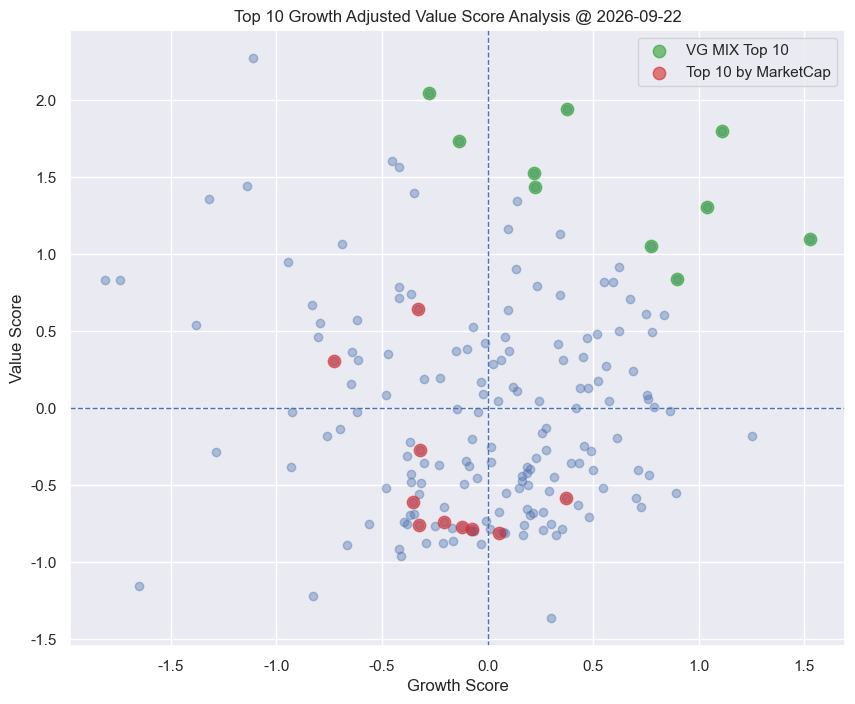

In [22]:
# 타겟일 지정 및 성장, 가치 Score 추출
target_date = '2026-09-22'
top_selection = 10
value_at = value_scores.loc[target_date]
growth_at = growth_scores.loc[target_date]
vg_mix_topn = vg_ranking.loc[target_date].nsmallest(top_selection)
topn_corps = list(vg_mix_topn.index)
market_cap_top10 = ['삼성전자', 'SK하이닉스', '현대차', 'LG에너지솔루션', '한화에어로스페이스', 'SK스퀘어', '삼성바이오로직스', '두산에너빌리티', '기아', '삼성물산']

# 성장 조정 가치 Score 4분면 시각화
plt.figure(figsize=(10,8))
plt.scatter(growth_at, value_at, alpha = 0.4) 
plt.scatter(growth_at[topn_corps], value_at[topn_corps], alpha=0.6, color="tab:green", s=80, label=f'VG MIX Top {top_selection}') 
plt.scatter(growth_at[market_cap_top10], value_at[market_cap_top10], alpha=0.6, color="tab:red", s=80, label=f'Top {top_selection} by MarketCap') 
# plt.scatter(growth_at[['이마트']], value_at[['이마트']], alpha=0.6, color="tab:blue", s=80, label=f'Top {top_selection} by MarketCap') 
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel('Growth Score')
plt.ylabel('Value Score')
plt.title(f'Top {top_selection} Growth Adjusted Value Score Analysis @ {target_date}')
plt.legend()
plt.show()

In [581]:
import pandas as pd

def get_top10_streak_all(df):
    """
    vg_ranking DF를 입력받아 {날짜: {종목: 연속체류일}} 도출
    (Top 10에 속한 종목들만 결과에 포함됨)
    """
    final_result = {}
    
    # 모든 종목의 실시간 스트릭을 관리할 딕셔너리
    current_streaks = {ticker: 0 for ticker in df.columns}
    
    for date, row in df.iterrows():
        # 데이터가 없는 날짜(NaN)는 건너뜀
        if row.isnull().all():
            continue
        
        # 1. 매일 모든 종목의 순위를 확인하여 스트릭 업데이트
        for ticker, rank in row.items():
            if pd.notnull(rank) and rank <= 10:
                # Top 10 안에 있으면 1 증가 (신규 진입이면 0+1=1)
                current_streaks[ticker] += 1
            else:
                # Top 10 밖으로 나가면 즉시 0으로 리셋
                current_streaks[ticker] = 0
        
        # 2. 오늘의 Top 10 종목들만 골라내어 {종목: 일수} 생성
        # 스트릭이 0보다 큰 종목들만 추출
        daily_active_streaks = {
            ticker: streak 
            for ticker, streak in current_streaks.items() 
            if streak > 0
        }
        
        # 3. 결과 딕셔너리에 날짜별로 저장
        date_str = date.strftime('%Y-%m-%d')
        final_result[date_str] = daily_active_streaks
        
    return final_result

# 실행 예시
streak_data = get_top10_streak_all(vg_ranking)

# 특정 날짜(예: 2026-04-10)의 Top 10 체류 현황 확인
print(streak_data['2026-04-10'])

{'영풍': 19, '한화': 133, '동원산업': 133, 'GS리테일': 2, '영원무역홀딩스': 11, '롯데쇼핑': 22, 'GS': 99, '이마트': 18, '한국타이어앤테크놀로지': 18, 'HD현대': 21}
